In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d
import matplotlib as mpl

plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #正常显示负号
pd.set_option('display.max_columns',6)
pd.set_option('display.max_rows',6)

In [ ]:
#读取市场数据
data_raw = pd.read_pickle(r"C:/Users/jimmy/Documents/workspace1/pfhedge-ty/stats/sse50_option_data_processed_20231110.pkl")

#按Dupire公式，计算总方差和远期在值程度
data_raw["w"] = data_raw["market_imp_vol"]**2 * data_raw["maturity"]  #计算总方差
data_raw["y"] = np.log(data_raw["exerciseprice"]/data_raw["F"])  #计算远期在值程度
option = data_raw.loc[data_raw["实虚值"]=="虚值"]  #后续主要使用虚值期权拟合
option = option.sort_values(["contract_month","y"])
option
 
print(np.sort(option["y"].unique()))
print(np.sort(option["maturity"].unique()))

[-0.1220607  -0.11474486 -0.10588243 -0.10243329 -0.10008179 -0.09276595
 -0.08390353 -0.08045439 -0.07857558 -0.07125975 -0.06239732 -0.05894818
 -0.05752218 -0.05020634 -0.04134391 -0.03789477 -0.03690289 -0.02958705
 -0.02072463 -0.01727549 -0.01670018 -0.00938434 -0.00052192  0.00292722
  0.00310245  0.01041828  0.01928071  0.02252053  0.02272985  0.02983637
  0.0386988   0.04156873  0.04214793  0.04888456  0.05774699  0.06026086
  0.06119613  0.0675767   0.07643912  0.07861     0.07988826  0.08592584
  0.09478826  0.0982374   0.10394434  0.11280677  0.11625591  0.12164392
  0.13050634  0.13903566  0.14789809  0.15613009  0.16499252]
[0.04958678 0.19421488 0.57024793 0.94628099]


In [ ]:
#插值函数，计算任意一点的总方差
def get_spline(data):  #用来事先计算好4个期限的样条函数值，后续就不用反复计算了
    spline = []
    for m in data["maturity"].unique():
        moneyness = data.loc[data["maturity"] == m]["y"]
        sample_volatility = data.loc[data["maturity"] == m]["w"]
        cs_k = CubicSpline(x = moneyness,y = sample_volatility,extrapolate=True)
        spline.append(cs_k)
    return spline
spline = get_spline(option)
def get_total_v(data,spline,y,t):
    total_v = [float(cs(y)) for cs in spline]
    f = interp1d(x =data["maturity"].unique(),y = total_v,kind = "linear",fill_value="extrapolate") #平远期插值相当于总方差的线性插值
    v = float(f(t))
    return v

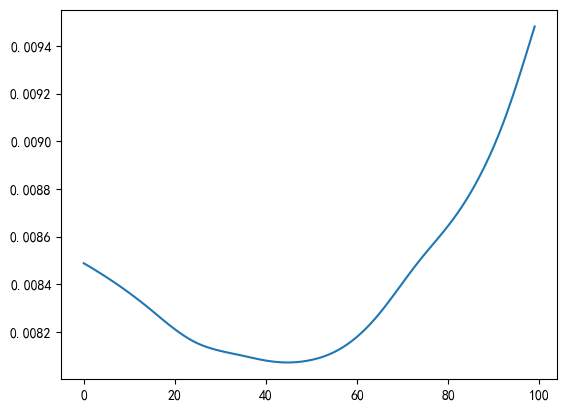

In [ ]:
total_v = np.zeros(100)
for idx,y in enumerate(np.linspace(-0.1,0.1,100)):
    total_v[idx] = get_total_v(option,spline,y,0.5)
plt.plot(total_v)
#波动率关于t的变化

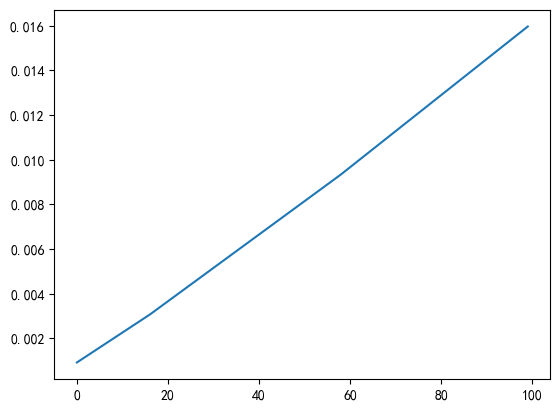

In [ ]:
total_v = np.zeros(100)
for idx,t in enumerate(np.linspace(0.05,0.94,100)):
    total_v[idx] = get_total_v(option,spline,-0.05,t)
plt.plot(total_v)
#波动率关于y的变化

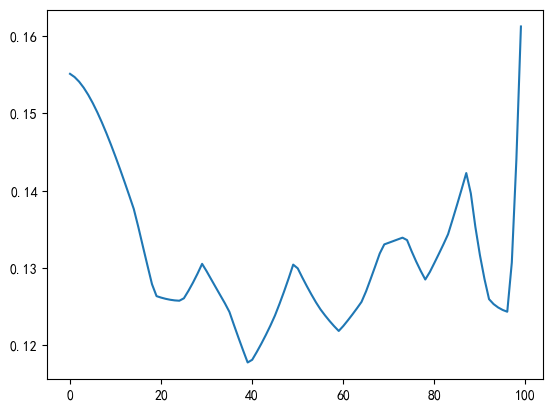

In [ ]:
#定义差分
def diff(data,spline,y,t):
    yt = get_total_v(data,spline,y,t)
    y_up = get_total_v(data,spline,y*(1+0.001),t)
    y_down = get_total_v(data,spline,y*(1-0.001),t)
    t_up = get_total_v(data,spline,y,t*(1+0.001))

    dw_dt = (t_up - yt)/(t*0.001)
    dw_dy = (y_up - y_down)/(y*0.001*2)
    dw_dy2 = (y_up + y_down - 2*yt)/(y*0.001)**2
    return dw_dt,dw_dy,dw_dy2

#该函数用于计算任意一点的局部波动率
def local_v(data,spline,y,t):
    w = get_total_v(data,spline,y,t)
    dw_dt,dw_dy,dw_dy2 = diff(data,spline,y,t)
    numetator = dw_dt
    denonimator = 1-y/w*dw_dy + 0.25*(-0.25 - 1/w + y**2/w**2) * (dw_dy**2) + 0.5* dw_dy2
    local_variance = numetator / denonimator
    if local_variance < 0:  #若存在套利机会，很可能会出现算出的结果为负数，这里简单处理一下
        local_variance  = 1e-8
    return np.sqrt(local_variance) #公式计算的是方差，我们返回标准差，即波动率

v_s = np.zeros(100)
for idx,y in enumerate(np.linspace(-0.1,0.1,100)):
    v_s[idx] = local_v(option,spline,y,0.3)
plt.plot(v_s)

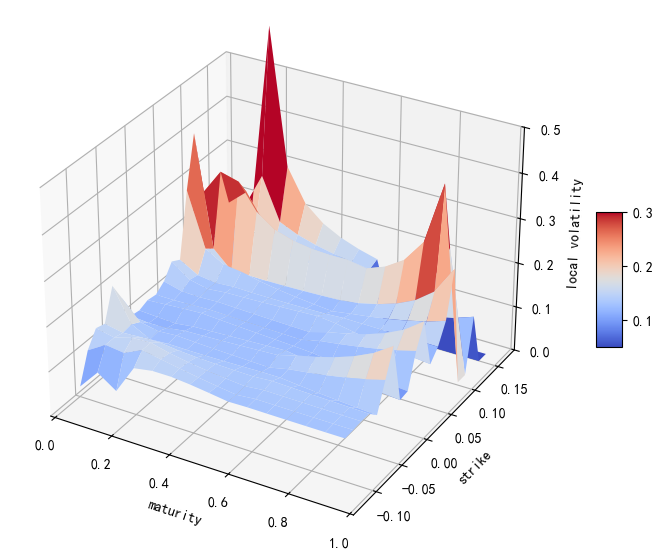

In [15]:
def plot_ivs(t,k,v):
    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection='3d')
    norm = mpl.colors.Normalize(vmin=0.05, vmax=0.3)
    # 绘图主程序
    surf = ax.plot_surface(t, k, v, rstride=1, cstride=1,
    cmap=plt.cm.coolwarm,norm = norm,linewidth=0.5, antialiased=True)
    # 设置坐标轴
    ax.set_xlabel('maturity')
    ax.set_ylabel('strike')
    ax.set_zlabel('local volatility')
    ax.set_zlim((0,0.5))
    fig.colorbar(surf, shrink=0.25, aspect=5)

def get_local_variance(data,spline):
    t_array = np.linspace(data["maturity"].min(),data["maturity"].max(),15)
    y_array = np.linspace(data["y"].min(),data["y"].max(),20)   
    t, y = np.meshgrid(t_array,y_array) 
    v = np.zeros_like(y)

    # 循环确定每个点的隐含波动率，上一步已经存储了k维度上的样条函数，循环的时候还需要t维度的样条插值，这样可以计算任意点的隐含波动率值
    for t_idx,t1 in enumerate(t_array):

        for y_idx,y1 in enumerate(y_array):
            v[y_idx,t_idx] = local_v(data,spline,y1,t1)
    return t,y,v
t,y,v = get_local_variance(option,spline)
plot_ivs(t,y,v)